# Phase 4: High-Frequency Feature Engineering (15T)
Load feeds_cleaned_15T.csv, engineer features, split, scale, and save outputs.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# Load data
df = pd.read_csv('feeds_cleaned_15T.csv', parse_dates=['created_at'], index_col='created_at')
print(f"Loaded feeds_cleaned_15T.csv: {df.shape}")

# Engineer target: 15-min ahead
df['target_pm2_5'] = df['pm2_5'].shift(-1)
print(f"Target created, NaNs at end: {df['target_pm2_5'].isnull().sum()}")

# Time features
df['hour_of_day'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['minute_of_hour'] = df.index.minute
print("Time features added")

# Lag features: t-15m, t-30m, t-45m, t-60m
df['pm2_5_lag_15m'] = df['pm2_5'].shift(1)
df['pm2_5_lag_30m'] = df['pm2_5'].shift(2)
df['pm2_5_lag_45m'] = df['pm2_5'].shift(3)
df['pm2_5_lag_60m'] = df['pm2_5'].shift(4)
df['temperature_lag_15m'] = df['temperature'].shift(1)
df['humidity_lag_15m'] = df['humidity'].shift(1)
df['pm10_lag_15m'] = df['pm10'].shift(1)
print("Lag features added")

# Rolling features: 1-hour average
df['pm2_5_roll_avg_1h'] = df['pm2_5'].shift(1).rolling(window=4).mean()
df['temperature_roll_avg_1h'] = df['temperature'].shift(1).rolling(window=4).mean()
print("Rolling features added")

# Clean NaNs
df_model = df.dropna()
print(f"After dropna: {df_model.shape}")

# Define X and y
y = df_model['target_pm2_5']
X = df_model.drop(['pm2_5', 'pm10', 'temperature', 'humidity', 'target_pm2_5'], axis=1)

# Remove redundant features based on correlation analysis
redundant_features = ['pm10_lag_15m']  # Example based on correlation heatmap
X = X.drop(columns=redundant_features)

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Features: {X.columns.tolist()}")

# Chronological split
split_percent = 0.8
split_point = int(len(X) * split_percent)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Data scaled")

# Save
np.save('X_train_15T.npy', X_train_scaled)
np.save('X_test_15T.npy', X_test_scaled)
y_train.to_csv('y_train_15T.csv', header=True)
y_test.to_csv('y_test_15T.csv', header=True)
joblib.dump(scaler, 'scaler_15T.pkl')
joblib.dump(X.columns.to_list(), 'feature_names_15T.pkl')
print("All files saved with _15T suffix")

Loaded feeds_cleaned_15T.csv: (14119, 4)
Target created, NaNs at end: 1
Time features added
Lag features added
Rolling features added
After dropna: (14114, 17)
X shape: (14114, 11), y shape: (14114,)
Features: ['hour_of_day', 'day_of_week', 'minute_of_hour', 'pm2_5_lag_15m', 'pm2_5_lag_30m', 'pm2_5_lag_45m', 'pm2_5_lag_60m', 'temperature_lag_15m', 'humidity_lag_15m', 'pm2_5_roll_avg_1h', 'temperature_roll_avg_1h']
Train: (11291, 11), Test: (2823, 11)
Data scaled
All files saved with _15T suffix
All files saved with _15T suffix


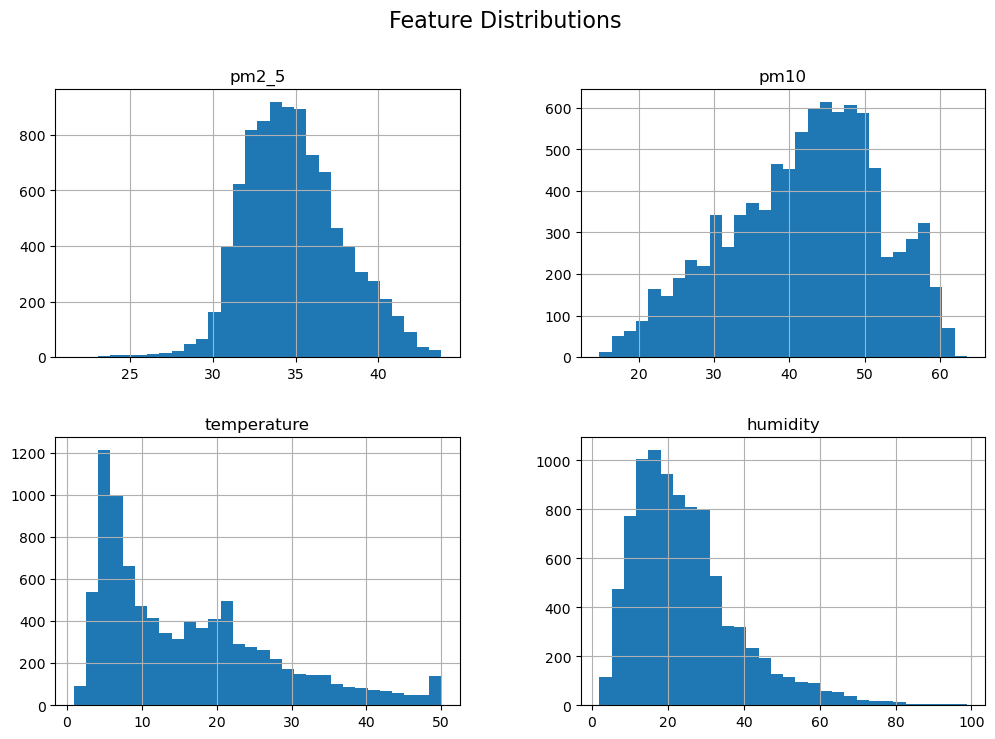

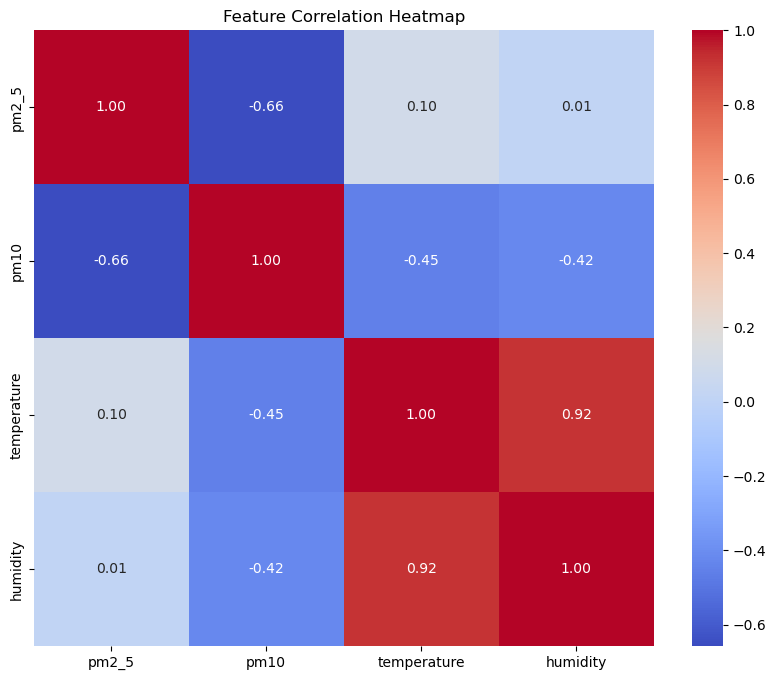

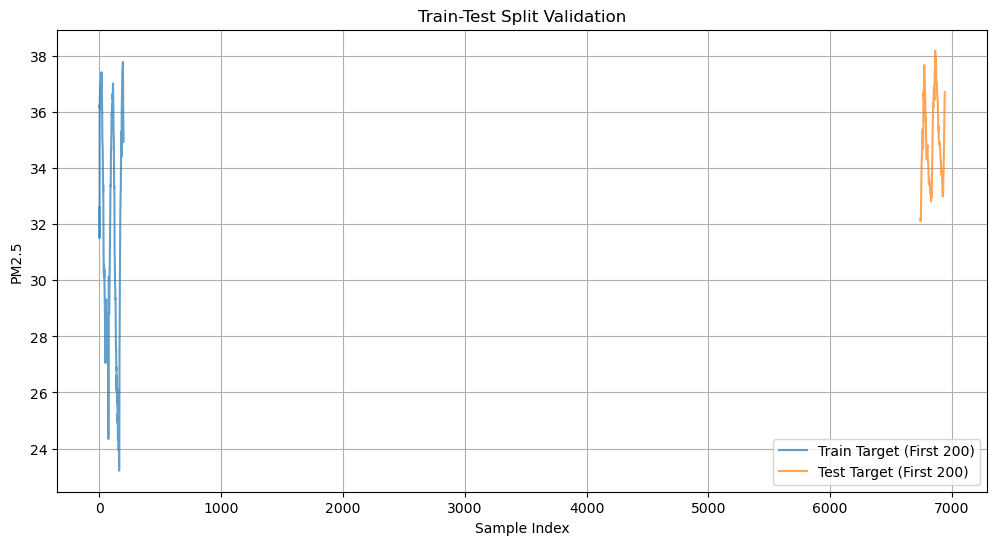

In [7]:
# Visualize feature distributions
import matplotlib.pyplot as plt
import seaborn as sns

# Define sensor columns
sensor_cols = ['pm2_5', 'pm10', 'temperature', 'humidity']

# Plot feature distributions
df[sensor_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle('Feature Distributions', fontsize=16)
plt.show()

# Correlation heatmap
corr = df[sensor_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# Train-test split validation
plt.figure(figsize=(12, 6))
plt.plot(y_train.values[:200], label='Train Target (First 200)', alpha=0.7)
plt.plot(range(len(y_train), len(y_train) + 200), y_test.values[:200], label='Test Target (First 200)', alpha=0.7)
plt.xlabel('Sample Index')
plt.ylabel('PM2.5')
plt.title('Train-Test Split Validation')
plt.legend()
plt.grid(True)
plt.show()